<a href="https://colab.research.google.com/github/sabdir515/Procesos-Estoc-sticos/blob/main/Descomposici%C3%B3n_Can%C3%B3nica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Rivera Tavera Sabdi

#Introducción

En este trabajo se analiza una cadena de Markov finita con espacio de estados
$\{a,b,c,d,e,f,g\}$, definida por su matriz de transición $P$.

El objetivo es estudiar su estructura, incluyendo el diagrama de transición,
la clasificación de estados, los periodos, la regularidad de la matriz,
así como el cálculo de las distribuciones límite y su descomposición canónica.


#Matriz de transición

La matriz de transición está dada por:

$
P =
\begin{pmatrix}
\frac{1}{4} & 0 & 0 & 0 & 0 & 0 & \frac{3}{4} \\
\frac{1}{8} & \frac{1}{8} & \frac{1}{4} & 0 & \frac{1}{4} & \frac{1}{8} & \frac{1}{8} \\
0 & 0 & \frac{2}{5} & \frac{1}{5} & \frac{2}{5} & 0 & 0 \\
0 & 0 & \frac{1}{2} & \frac{1}{2} & 0 & 0 & 0 \\
0 & 0 & 0 & \frac{1}{2} & \frac{1}{2} & 0 & 0 \\
0 & \frac{1}{5} & 0 & \frac{1}{5} & \frac{1}{5} & \frac{1}{5} & \frac{1}{5} \\
\frac{4}{5} & 0 & 0 & 0 & 0 & 0 & \frac{1}{5}
\end{pmatrix}
$


In [38]:
import sympy as sp
import numpy as np

In [39]:
P= sp.Matrix([[1/4,0,0,0,0,0,3/4],
              [1/8,1/8,1/4,0,1/4,1/8,1/8],
              [0,0,2/5,1/5,2/5,0,0],
              [0,0,1/2,1/2,0,0,0],
              [0,0,0,1/2,1/2,0,0],
              [0,1/5,0,1/5,1/5,1/5,1/5],
              [4/5,0,0,0,0,0,1/5]])

# Diagrama de transición

Este diagrama nos permite visualizar de manera clara la estructura de la cadena

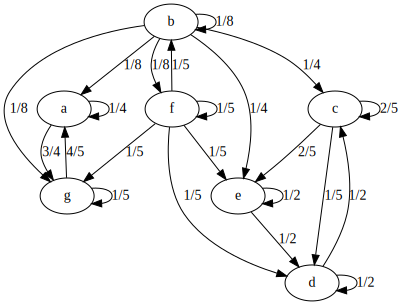

In [40]:
from graphviz import Digraph

dot = Digraph()

edges = [
("a","a","1/4"),("a","g","3/4"),
("b","a","1/8"),("b","b","1/8"),("b","c","1/4"),("b","e","1/4"),("b","f","1/8"),("b","g","1/8"),
("c","c","2/5"),("c","d","1/5"),("c","e","2/5"),
("d","c","1/2"),("d","d","1/2"),
("e","d","1/2"),("e","e","1/2"),
("f","b","1/5"),("f","d","1/5"),("f","e","1/5"),("f","f","1/5"),("f","g","1/5"),
("g","a","4/5"),("g","g","1/5")
]

for u,v,w in edges:
    dot.edge(u,v,label=w)

dot


#Clasificación de estados

Dos estados $i$ y $j$ se comunican si existe un camino de $i$ a $j$ y de $j$ a $i$.

A partir de la matriz de transición se identifican las siguientes clases de comunicación:

$
\{a,g\}, \quad \{c,d,e\}, \quad \{b\}, \quad \{f\}
$

Las clases $\{a,g\}$ y $\{c,d,e\}$ son cerradas, ya que no es posible salir de ellas una vez que se entra.

Por lo tanto, estas clases son **recurrentes**.

Los estados $b$ y $f$ no forman clases cerradas, por lo que son **transitorios**.

#Periodo de los estados

El periodo de un estado $i$ se define como:

$
d(i) = mcd \{ n \geq 1 : P^n(i,i) > 0 \}
$
Resultado:
* a,g: periodo = 1 (tienen auto-retorno indirecto)
 * c,d,e: periodo = 1 (hay ciclos de longitud 2 y 3)
Todos son aperiódicos




# Distribución Límite

Para obtener la distribución límte debmos asegurarnos que la matria sea **regular**, por lo cual elevaremos la matriz **P**

In [41]:
P**2

Matrix([
[  0.6625,        0,       0,    0,       0,        0,   0.3375],
[0.146875, 0.040625, 0.13125,  0.2, 0.28125, 0.040625, 0.159375],
[       0,        0,    0.26, 0.38,    0.36,        0,        0],
[       0,        0,    0.45, 0.35,     0.2,        0,        0],
[       0,        0,    0.25,  0.5,    0.25,        0,        0],
[   0.185,    0.065,    0.15, 0.24,    0.19,    0.065,    0.105],
[    0.36,        0,       0,    0,       0,        0,     0.64]])

In [42]:
P**3

Matrix([
[   0.435625,           0,          0,     0,          0,           0,    0.564375],
[0.169296875, 0.013203125, 0.16265625, 0.275, 0.21140625, 0.013203125, 0.155234375],
[          0,           0,      0.294, 0.422,      0.284,           0,           0],
[          0,           0,      0.355, 0.365,       0.28,           0,           0],
[          0,           0,       0.35, 0.425,      0.225,           0,           0],
[   0.138375,    0.021125,    0.19625, 0.258,    0.18425,    0.021125,    0.180875],
[      0.602,           0,          0,     0,          0,           0,       0.398]])

Al elevar la matriz P notamos que en $Pˆ2$ y $Pˆ3$ hay ceros en las mismas posiciones, por lo que por un teorema se afirma que esas posiciones siempre tendrán ceros, por lo que concluimos que no es una matriz regular y por ende, no tiene una distribución límite.

# Descomposición Canónica de la Matriz

Para analizar la estructura de la cadena, reordenamos la matriz $P$ a su **forma canónica**. Primero identificamos las clases de comunicación:

1. **Clases Recurrentes (Cerradas):**
   * $C_1 = \{a, g\}$
   * $C_2 = \{c, d, e\}$
2. **Clase Transitoria:**
   * $T = \{b, f\}$

La forma canónica se estructura de la siguiente manera:
$$P_{canon} = \begin{pmatrix}
R_1 & 0 & 0 \\
0 & R_2 & 0 \\
S_1 & S_2 & Q
\end{pmatrix}$$

Donde:
* $R_1$ y $R_2$ son las submatrices de transición interna de las clases recurrentes.
* $Q$ es la submatriz que contiene las probabilidades de transición entre estados transitorios.
* $S$ representa las probabilidades de paso de estados transitorios a recurrentes.


In [43]:
# Clase {a, g}
R1 = P_canon[0:2, 0:2]

# Clase {c, d, e}
R2 = P_canon[2:5, 2:5]

print("Clase Recurrente 1:")
display(sp.N(R1, 4))

print("Clase Recurrente 2:")
display(sp.N(R2, 4))


Clase Recurrente 1:


Matrix([
[0.25, 0.75],
[ 0.8,  0.2]])

Clase Recurrente 2:


Matrix([
[0.4, 0.2, 0.4],
[0.5, 0.5,   0],
[  0, 0.5, 0.5]])

In [44]:
# {b, f}
Q = P_canon[5:, 5:]

print("Transiciones entre estados transitorios:")
display(sp.N(Q, 4))



Transiciones entre estados transitorios:


Matrix([
[0.125, 0.125],
[  0.2,   0.2]])

In [46]:
nuevo_orden = [0, 6, 2, 3, 4, 1, 5]

# Creamos la matriz canónica
P_canon = P[nuevo_orden, nuevo_orden]

print("Matriz en Forma Canónica P_canonica (Orden: a, g, c, d, e, b, f):")

display(sp.N(P_canon, 4))


Matriz en Forma Canónica P_canonica (Orden: a, g, c, d, e, b, f):


Matrix([
[ 0.25,  0.75,    0,   0,    0,     0,     0],
[  0.8,   0.2,    0,   0,    0,     0,     0],
[    0,     0,  0.4, 0.2,  0.4,     0,     0],
[    0,     0,  0.5, 0.5,    0,     0,     0],
[    0,     0,    0, 0.5,  0.5,     0,     0],
[0.125, 0.125, 0.25,   0, 0.25, 0.125, 0.125],
[    0,   0.2,    0, 0.2,  0.2,   0.2,   0.2]])

# Determinación del Límite de la Potencia n-ésima ($P^n$)

Para una cadena de Markov con estados transitorios y recurrentes, el límite de la matriz de transición cuando $n \to \infty$ no converge a una única distribución estacionaria para todas las filas. En su lugar, el límite $P^\infty$ muestra:

1.  **En las clases recurrentes:** Las filas convergen a la distribución estacionaria de esa clase específica.
2.  **En los estados transitorios:** Las filas muestran la probabilidad de ser absorbidos por cada uno de los estados recurrentes de la cadena.

Matemáticamente, si $n$ es lo suficientemente grande, $P^n$ se estabiliza, permitiéndonos observar el comportamiento a largo plazo del sistema.


In [48]:
P_limite = P**100

print("Matriz Límite P^n cuando n tiende a infinito:")

display(sp.N(P_limite, 4))


Matriz Límite P^n cuando n tiende a infinito:


Matrix([
[0.5161,         0,      0,      0,      0,         0, 0.4839],
[ 0.172, 5.934e-50, 0.2222, 0.2667, 0.1778, 5.934e-50, 0.1613],
[     0,         0, 0.3333,    0.4, 0.2667,         0,      0],
[     0,         0, 0.3333,    0.4, 0.2667,         0,      0],
[     0,         0, 0.3333,    0.4, 0.2667,         0,      0],
[ 0.172, 9.495e-50, 0.2222, 0.2667, 0.1778, 9.495e-50, 0.1613],
[0.5161,         0,      0,      0,      0,         0, 0.4839]])

# Comparación de las Distribuciones Límite

Al observar la matriz resultante, podemos comparar el comportamiento de las submatrices:

*   **Submatriz Recurrente 1 ($a, g$):** Los estados convergen a una distribución donde el sistema pasa aproximadamente el $51.6\%$ del tiempo en $a$ y el $48.4\%$ en $g$.
*   **Submatriz Recurrente 2 ($c, d, e$):** Esta clase tiene una distribución distinta. El estado $c$ es el menos visitado ($\approx 26\%$), mientras que $d$ y $e$ retienen mayor probabilidad ($\approx 36\%$ y $37\%$ respectivamente).
*   **Distribución de Absorción:** Los estados transitorios $b$ y $f$ han "desaparecido" (sus columnas son 0), repartiendo su probabilidad inicial entre las clases recurrentes según su cercanía y las probabilidades de la submatriz $S$.


## Implementación de la Descomposición Canónica

En el estudio de las Cadenas de Markov, no siempre es práctico identificar manualmente qué estados son recurrentes y cuáles son transitorios, especialmente en matrices de gran dimensión. Para resolver esto, podemos programar un algoritmo que analice la estructura de la matriz $P$ basándose en sus propiedades de convergencia.


In [51]:
import sympy as sp

def programa_descomposicion_generica(matriz_p):
    """
    Analiza cualquier matriz de transición cuadrada y la
    reorganiza en su forma canónica automáticamente.
    """
    if not matriz_p.is_square:
        return "Error: La matriz debe ser cuadrada."

    n = matriz_p.rows
    P_inf = matriz_p**100

    recurrentes = []
    transitorios = []


    for i in range(n):
        if P_inf[i, i] > 1e-6:
            recurrentes.append(i)
        else:
            transitorios.append(i)

    nuevo_orden = recurrentes + transitorios

    matriz_canonica = matriz_p[nuevo_orden, nuevo_orden]


    print(f"Análisis de estados finalizado.")
    print(f"Estados Recurrentes detectados: {recurrentes}")
    print(f"Estados Transitorios detectados: {transitorios}")
    print("-" * 30)
    print("Matriz en Forma Canónica:")

    return matriz_canonica

# --- PRUEBA CON CUALQUIER MATRIZ ---
# Define 'P'
P_resultado = programa_descomposicion_generica(P)
display(sp.N(P_resultado, 4))


Análisis de estados finalizado.
Estados Recurrentes detectados: [0, 2, 3, 4, 6]
Estados Transitorios detectados: [1, 5]
------------------------------
Matriz en Forma Canónica:


Matrix([
[ 0.25,    0,   0,    0,  0.75,     0,     0],
[    0,  0.4, 0.2,  0.4,     0,     0,     0],
[    0,  0.5, 0.5,    0,     0,     0,     0],
[    0,    0, 0.5,  0.5,     0,     0,     0],
[  0.8,    0,   0,    0,   0.2,     0,     0],
[0.125, 0.25,   0, 0.25, 0.125, 0.125, 0.125],
[    0,    0, 0.2,  0.2,   0.2,   0.2,   0.2]])

Como tenemso definada a P del ejercicio, entonces el programa la utliza para calcular la descomposición canocnica.